In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Loan Prediction Dataset Using LogisticRegression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing 


- Handle missing values.


- Encode categorical features (e.g., Gender, Education).


- Apply feature scaling (especially important for Logistic Regression).


- Split the dataset into training and test sets (70/30).


## 1. Load and Explore the Data


In [ ]:
df = pd.read_csv('Loan.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.shape

(614, 13)

2. Data Cleaning


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
# fill Gender missing values with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

C:\Users\marwa\AppData\Local\Temp\ipykernel_268\3716572402.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


In [ ]:
# fill Married missing values with mode
df['Married'].fillna(df['Married'].mode()[0], inplace=True)


C:\Users\marwa\AppData\Local\Temp\ipykernel_268\205678176.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Married'].fillna(df['Married'].mode()[0], inplace=True)


In [ ]:
# fill Dependents missing value related by Married status
df.loc[(df['Dependents'].isnull()) & (df['Married'] == 'Yes'), 'Dependents'] = '1'
df.loc[(df['Dependents'].isnull()) & (df['Married'] == 'No'), 'Dependents'] = '0'

# للتأكد إن مفيش null باقي:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


C:\Users\marwa\AppData\Local\Temp\ipykernel_268\746481078.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


In [ ]:
# Self_Employed missing values with ApplicantIncome mode
midOfApplicantIncome = df['ApplicantIncome'].median()
df.loc[(df['Self_Employed'].isnull()) & (df['ApplicantIncome'] <= midOfApplicantIncome), 'Self_Employed'] = 'No'
df.loc[(df['Self_Employed'].isnull()) & (df['ApplicantIncome'] > midOfApplicantIncome), 'Self_Employed'] = 'Yes'

# نوضح ان مفيش null باقي:
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

C:\Users\marwa\AppData\Local\Temp\ipykernel_268\418143620.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)


In [ ]:
df.groupby('Self_Employed')['LoanAmount'].describe()


,count,mean,std,min,25%,50%,75%,max
Self_Employed,,,,,,,,
No,502.0,141.165339,79.097848,9.0,100.0,124.5,160.00,700.0
Yes,90.0,175.677778,111.365057,25.0,108.5,150.0,190.75,650.0


In [ ]:
# Fill missing LoanAmount values based on Self_Employed status using median
median_yes = df.loc[df['Self_Employed'] == 'Yes', 'LoanAmount'].median()
median_no = df.loc[df['Self_Employed'] == 'No', 'LoanAmount'].median()

df.loc[df['LoanAmount'].isnull() & (df['Self_Employed'] == 'Yes'), 'LoanAmount'] = median_yes
df.loc[df['LoanAmount'].isnull() & (df['Self_Employed'] == 'No'), 'LoanAmount'] = median_no


In [ ]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
# fill Loan_Amount_Term missing values with mode
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)


C:\Users\marwa\AppData\Local\Temp\ipykernel_268\3217550144.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)


In [ ]:
import numpy as np

# نحسب الدخل الكلي
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# القيمة الأكثر شيوعًا fallback
mode_credit = df['Credit_History'].mode()[0]

def fill_credit(row):
    if pd.isnull(row['Credit_History']):
        # 1️⃣ متزوج و دخله الكلي عالي
        if row['Married'] == 'Yes' and row['TotalIncome'] > 8000:
            return 1
        # 2️⃣ غير متزوج و دخله عالي جدًا
        elif row['Married'] == 'No' and row['TotalIncome'] > 10000:
            return 1
        # 3️⃣ خريج و دخله جيد
        elif row['Education'] == 'Graduate' and row['TotalIncome'] > 6000:
            return 1
        # 4️⃣ Self_Employed و دخله منخفض
        elif row['Self_Employed'] == 'Yes' and row['TotalIncome'] < 5000:
            return 0
        # 5️⃣ من منطقة حضرية أو شبه حضرية و دخله كويس
        elif row['Property_Area'] in ['Urban', 'Semiurban'] and row['TotalIncome'] > 7000:
            return 1
        # 6️⃣ القرض كبير مقارنة بالدخل
        elif row['LoanAmount'] > (row['TotalIncome'] * 0.4):
            return 0
        # 7️⃣ أي حالة تانية نحط القيمة الشائعة
        else:
            return mode_credit
    else:
        return row['Credit_History']

# تطبيق القواعد
df['Credit_History'] = df.apply(fill_credit, axis=1)


In [ ]:
df.isnull().sum()   

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
TotalIncome          0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
 13  TotalIncome        614 non-null    float64
dtypes: float64(5), int64(1), object(8)
memory usage: 67.3+ KB


## Encode categorical features 

Gender → Male/Female (Label Encoding)

Married → Yes/No (Label Encoding)

Education → Graduate/Not Graduate (Label Encoding)

Self_Employed → Yes/No (Label Encoding)

Property_Area → Urban/Semiurban/Rural (One-Hot Encoding)

Dependents → 0, 1, 2, 3+ (replace +3 with 3)

Loan_Status → Target variable (Y/N → 1/0)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1️⃣ إصلاح عمود Dependents
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# 2️⃣ الأعمدة اللي فيها قيمتين فقط → Label Encoding
label_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])


# 4️⃣ نراجع النتيجة
print(df.head())
print("\nShape ", df.shape)
print("\n Types of Data Type\n", df.dtypes)


    Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0  LP001002       1        0           0          0              0   
1  LP001003       1        1           1          0              0   
2  LP001005       1        1           0          0              1   
3  LP001006       1        1           0          1              0   
4  LP001008       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       124.5             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area  Loan_Status  TotalIncome  
0             1.0         Urban            1       5849.0  
1             1.0         Rural 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    int64  
 13  TotalIncome        614 non-null    float64
dtypes: float64(5), int64(7), object(2)
memory usage: 67.3+ KB


In [ ]:
# 3️⃣ One-Hot Encoding لعمود Property_Area
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Gender                   614 non-null    int64  
 2   Married                  614 non-null    int64  
 3   Dependents               614 non-null    int64  
 4   Education                614 non-null    int64  
 5   Self_Employed            614 non-null    int64  
 6   ApplicantIncome          614 non-null    int64  
 7   CoapplicantIncome        614 non-null    float64
 8   LoanAmount               614 non-null    float64
 9   Loan_Amount_Term         614 non-null    float64
 10  Credit_History           614 non-null    float64
 11  Loan_Status              614 non-null    int64  
 12  TotalIncome              614 non-null    float64
 13  Property_Area_Semiurban  614 non-null    bool   
 14  Property_Area_Urban      6

## Outliers

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome']:
    outliers, low, up = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers (out of {len(df)})")
    print(f"Lower bound = {low:.2f}, Upper bound = {up:.2f}")
    print("-"*40)


ApplicantIncome: 50 outliers (out of 614)
Lower bound = -1498.75, Upper bound = 10171.25
----------------------------------------
CoapplicantIncome: 18 outliers (out of 614)
Lower bound = -3445.88, Upper bound = 5743.12
----------------------------------------
LoanAmount: 41 outliers (out of 614)
Lower bound = 3.50, Upper bound = 261.50
----------------------------------------
TotalIncome: 50 outliers (out of 614)
Lower bound = -867.62, Upper bound = 12555.38
----------------------------------------


In [ ]:
df['ApplicantIncome'] = np.where(df['ApplicantIncome'] > 10171.25, 10171.25, df['ApplicantIncome'])
df['CoapplicantIncome'] = np.where(df['CoapplicantIncome'] > 4166.50, 4166.50, df['CoapplicantIncome'])



In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome']:
    outliers, low, up = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers (out of {len(df)})")
    print(f"Lower bound = {low:.2f}, Upper bound = {up:.2f}")
    print("-"*40)


ApplicantIncome: 0 outliers (out of 614)
Lower bound = -1498.75, Upper bound = 10171.25
----------------------------------------
CoapplicantIncome: 0 outliers (out of 614)
Lower bound = -3445.88, Upper bound = 5743.12
----------------------------------------
LoanAmount: 41 outliers (out of 614)
Lower bound = 3.50, Upper bound = 261.50
----------------------------------------
TotalIncome: 50 outliers (out of 614)
Lower bound = -867.62, Upper bound = 12555.38
----------------------------------------


In [ ]:
# update TotalIncome after handling outliers
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [ ]:
Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# نحذف الصفوف اللي فيها قيم أقل من الحد الأدنى أو أكبر من الحد الأعلى
df = df[(df['LoanAmount'] >= lower_bound) & (df['LoanAmount'] <= upper_bound)]


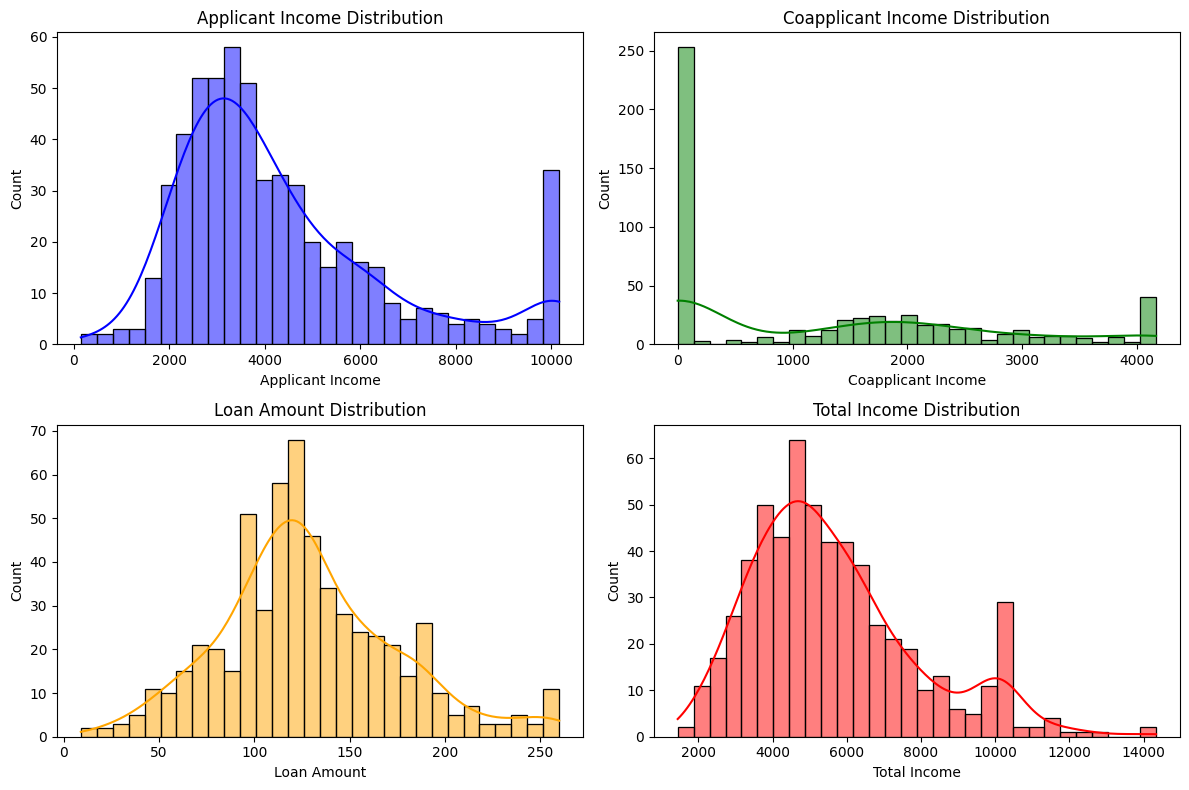

In [ ]:
# Drow Distributions after handling outliers

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(df['ApplicantIncome'], kde=True, bins=30, color='blue')
plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')
plt.subplot(2, 2, 2)
sns.histplot(df['CoapplicantIncome'], kde=True, bins=30, color='green')
plt.title('Coapplicant Income Distribution')
plt.xlabel('Coapplicant Income')
plt.subplot(2, 2, 3)
sns.histplot(df['LoanAmount'], kde=True, bins=30, color='orange')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.subplot(2, 2, 4)
sns.histplot(df['TotalIncome'], kde=True, bins=30, color='red')
plt.title('Total Income Distribution')
plt.xlabel('Total Income')
plt.tight_layout()
plt.show()


## Feature Engineering ✨

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 573 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  573 non-null    object 
 1   Gender                   573 non-null    int64  
 2   Married                  573 non-null    int64  
 3   Dependents               573 non-null    int64  
 4   Education                573 non-null    int64  
 5   Self_Employed            573 non-null    int64  
 6   ApplicantIncome          573 non-null    float64
 7   CoapplicantIncome        573 non-null    float64
 8   LoanAmount               573 non-null    float64
 9   Loan_Amount_Term         573 non-null    float64
 10  Credit_History           573 non-null    float64
 11  Loan_Status              573 non-null    int64  
 12  TotalIncome              573 non-null    float64
 13  Property_Area_Semiurban  573 non-null    bool   
 14  Property_Area_Urban      573 no

In [ ]:
# نسبه القرض الي الدخل الكلي
df['Loan_to_TotalIncome_Ratio'] = df['LoanAmount'] / df['TotalIncome']


# تحويل مده القرض من شهور الي سنوات
df['Loan_Amount_Term_Years'] = df['Loan_Amount_Term'] / 12





## Drop columns 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 573 entries, 0 to 613
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Loan_ID                    573 non-null    object 
 1   Gender                     573 non-null    int64  
 2   Married                    573 non-null    int64  
 3   Dependents                 573 non-null    int64  
 4   Education                  573 non-null    int64  
 5   Self_Employed              573 non-null    int64  
 6   ApplicantIncome            573 non-null    float64
 7   CoapplicantIncome          573 non-null    float64
 8   LoanAmount                 573 non-null    float64
 9   Loan_Amount_Term           573 non-null    float64
 10  Credit_History             573 non-null    float64
 11  Loan_Status                573 non-null    int64  
 12  TotalIncome                573 non-null    float64
 13  Property_Area_Semiurban    573 non-null    bool   
 14 

In [ ]:
df.drop(['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term'], axis=1, inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 573 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     573 non-null    int64  
 1   Married                    573 non-null    int64  
 2   Dependents                 573 non-null    int64  
 3   Education                  573 non-null    int64  
 4   Self_Employed              573 non-null    int64  
 5   LoanAmount                 573 non-null    float64
 6   Credit_History             573 non-null    float64
 7   Loan_Status                573 non-null    int64  
 8   TotalIncome                573 non-null    float64
 9   Property_Area_Semiurban    573 non-null    bool   
 10  Property_Area_Urban        573 non-null    bool   
 11  Loan_to_TotalIncome_Ratio  573 non-null    float64
 12  Loan_Amount_Term_Years     573 non-null    float64
dtypes: bool(2), float64(5), int64(6)
memory usage: 54.8 KB


In [ ]:
df.describe()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,Loan_Status,TotalIncome,Loan_to_TotalIncome_Ratio,Loan_Amount_Term_Years
count,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000
mean,0.813264,0.645724,0.724258,0.232112,0.144852,128.527051,0.848168,0.692845,5637.743316,0.024281,28.534031
std,0.390040,0.478711,0.977396,0.422549,0.352259,46.417427,0.359172,0.461717,2242.253917,0.008422,5.404703
min,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,1442.000000,0.003785,1.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,100.000000,1.000000,0.000000,4014.000000,0.019776,30.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,124.500000,1.000000,1.000000,5185.000000,0.024149,30.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,155.000000,1.000000,1.000000,6700.000000,0.028039,30.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,260.000000,1.000000,1.000000,14337.750000,0.082712,40.000000


## Scaling Section


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


In [ ]:
# Standard Scaling made Mean=0 and Std=1 
scaler = StandardScaler()
scaled_cols = ['LoanAmount', 'TotalIncome', 'Loan_to_TotalIncome_Ratio', 'Loan_Amount_Term_Years']

df[scaled_cols] = scaler.fit_transform(df[scaled_cols])


In [ ]:
df.describe()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Credit_History,Loan_Status,TotalIncome,Loan_to_TotalIncome_Ratio,Loan_Amount_Term_Years
count,573.000000,573.000000,573.000000,573.000000,573.000000,5.730000e+02,573.000000,573.000000,5.730000e+02,5.730000e+02,5.730000e+02
mean,0.813264,0.645724,0.724258,0.232112,0.144852,-2.077066e-16,0.848168,0.692845,2.294073e-16,1.302042e-16,-3.038097e-16
std,0.390040,0.478711,0.977396,0.422549,0.352259,1.000874e+00,0.359172,0.461717,1.000874e+00,1.000874e+00,1.000874e+00
min,0.000000,0.000000,0.000000,0.000000,0.000000,-2.577297e+00,0.000000,0.000000,-1.872852e+00,-2.435700e+00,-5.098909e+00
25%,1.000000,0.000000,0.000000,0.000000,0.000000,-6.151133e-01,1.000000,0.000000,-7.247895e-01,-5.353712e-01,2.714764e-01
50%,1.000000,1.000000,0.000000,0.000000,0.000000,-8.683310e-02,1.000000,1.000000,-2.020908e-01,-1.575556e-02,2.714764e-01
75%,1.000000,1.000000,1.000000,0.000000,0.000000,5.708218e-01,1.000000,1.000000,4.741590e-01,4.465006e-01,2.714764e-01
max,1.000000,1.000000,3.000000,1.000000,1.000000,2.834880e+00,1.000000,1.000000,3.883418e+00,6.943467e+00,2.123333e+00


## Split the dataset into training and test sets (70/30).

In [ ]:
# Split the dataset into training and test sets (70/30).
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


#  Logistic Regression

In [59]:
# Check class distribution
print("Class distribution in training set:")
print(y_train.value_counts())
print(f"\nClass 0 (Not Approved): {y_train.value_counts()[0]} samples")
print(f"Class 1 (Approved): {y_train.value_counts()[1]} samples")
print(f"Class imbalance ratio: {y_train.value_counts()[1] / y_train.value_counts()[0]:.2f}:1")

# Initialize and train logistic regression model with class_weight='balanced'
# This automatically adjusts weights inversely proportional to class frequencies
# to handle the class imbalance issue (low recall for class 0)
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)

Class distribution in training set:
Loan_Status
1    317
0    141
Name: count, dtype: int64

Class 0 (Not Approved): 141 samples
Class 1 (Approved): 317 samples
Class imbalance ratio: 2.25:1


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [60]:
# Make predictions
y_pred = logreg.predict(X_test)

In [61]:
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[20 15]
 [ 8 72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.57      0.63        35
           1       0.83      0.90      0.86        80

    accuracy                           0.80       115
   macro avg       0.77      0.74      0.75       115
weighted avg       0.79      0.80      0.79       115



# Implement L1 & L2

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)

lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8313953488372093

Confusion Matrix:
 [[ 28  27]
 [  2 115]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.51      0.66        55
           1       0.81      0.98      0.89       117

    accuracy                           0.83       172
   macro avg       0.87      0.75      0.77       172
weighted avg       0.85      0.83      0.81       172



In [64]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge_model = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, max_iter=1000, random_state=42)

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8347826086956521

Confusion Matrix:
 [[17 18]
 [ 1 79]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.49      0.64        35
           1       0.81      0.99      0.89        80

    accuracy                           0.83       115
   macro avg       0.88      0.74      0.77       115
weighted avg       0.85      0.83      0.82       115



# Take User Input + Predict

In [55]:
# === Cell 1: Imports ===
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Assume scaler and logreg are already trained and saved
# If not, you would need to train them before prediction

In [56]:
# === Cell 2: Collect User Input ===
print("=== Loan Prediction System ===\n")

test_data = {
    'Gender': input("Enter Gender (Male/Female): "),
    'Married': input("Married? (Yes/No): "),
    'Dependents': input("Number of Dependents (0/1/2/3+): "),
    'Education': input("Education (Graduate/Not Graduate): "),
    'Self_Employed': input("Self Employed? (Yes/No): "),
    'ApplicantIncome': float(input("Applicant Income: ")),
    'CoapplicantIncome': float(input("Coapplicant Income: ")),
    'LoanAmount': float(input("Loan Amount: ")),
    'Loan_Amount_Term': float(input("Loan Term (in months): ")),
    'Credit_History': float(input("Credit History (1.0 = good, 0.0 = bad): ")),
    'Property_Area': input("Property Area (Urban/Semiurban/Rural): ")
}

user_df = pd.DataFrame([test_data])

=== Loan Prediction System ===



In [57]:
# === Cell 3: Preprocessing ===

# 1. Handle Dependents
user_df['Dependents'] = user_df['Dependents'].replace('3+', 3).astype(int)

# 2. Label Encoding
label_cols = ['Gender', 'Married', 'Education', 'Self_Employed']
for col in label_cols:
    le = LabelEncoder()
    if col == 'Gender':
        le.fit(['Female', 'Male'])
    elif col == 'Married':
        le.fit(['No', 'Yes'])
    elif col == 'Education':
        le.fit(['Graduate', 'Not Graduate'])
    elif col == 'Self_Employed':
        le.fit(['No', 'Yes'])
    user_df[col] = le.transform(user_df[col])

# 3. Create TotalIncome
user_df['TotalIncome'] = user_df['ApplicantIncome'] + user_df['CoapplicantIncome']

# 4. Derived features
user_df['Loan_to_TotalIncome_Ratio'] = user_df['LoanAmount'] / user_df['TotalIncome']
user_df['Loan_Amount_Term_Years'] = user_df['Loan_Amount_Term'] / 12

# 5. Handle outliers
user_df['ApplicantIncome'] = user_df['ApplicantIncome'].clip(upper=10171.25)
user_df['CoapplicantIncome'] = user_df['CoapplicantIncome'].clip(upper=4166.50)
user_df['TotalIncome'] = user_df['ApplicantIncome'] + user_df['CoapplicantIncome']
user_df['Loan_to_TotalIncome_Ratio'] = user_df['LoanAmount'] / user_df['TotalIncome']

# 6. One-Hot Encoding for Property_Area
user_df['Property_Area_Semiurban'] = (user_df['Property_Area'] == 'Semiurban').astype(int)
user_df['Property_Area_Urban'] = (user_df['Property_Area'] == 'Urban').astype(int)
user_df = user_df.drop('Property_Area', axis=1)

# 7. Drop unused columns
user_df = user_df.drop(['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term'], axis=1)

# 8. Ensure column order
expected_columns = [
    'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
    'LoanAmount', 'Credit_History', 'TotalIncome',
    'Property_Area_Semiurban', 'Property_Area_Urban',
    'Loan_to_TotalIncome_Ratio', 'Loan_Amount_Term_Years'
]
user_df = user_df[expected_columns]

# 9. Scale numerical features
scaled_cols = ['LoanAmount', 'TotalIncome', 'Loan_to_TotalIncome_Ratio', 'Loan_Amount_Term_Years']
user_df[scaled_cols] = scaler.transform(user_df[scaled_cols])

C:\Users\marwa\AppData\Local\Temp\ipykernel_268\1304114965.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_df['Dependents'] = user_df['Dependents'].replace('3+', 3).astype(int)


In [58]:
# === Cell 4: Prediction ===
prediction = logreg.predict(user_df)[0]
prediction_proba = logreg.predict_proba(user_df)[0]

print("\n=== Prediction Result ===")
print(f"Prediction: {'APPROVED ✔️✔️' if prediction == 1 else 'NOT APPROVED ❌'}")
print(f"Confidence: {prediction_proba[prediction]*100:.2f}%")
print(f"Probability of Approval: {prediction_proba[1]*100:.2f}%")
print(f"Probability of Rejection: {prediction_proba[0]*100:.2f}%")


=== Prediction Result ===
Prediction: APPROVED ✔️✔️
Confidence: 88.88%
Probability of Approval: 88.88%
Probability of Rejection: 11.12%
